In [3]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

kx, ky = 0, 0
t1, t2, M = 1.0, 0.0, 0.2
a_vecs = [np.array([0.0, -1.0]), np.array([np.sqrt(3)/2, 0.5]), np.array([-np.sqrt(3)/2, 0.5])]
b_vecs = [a_vecs[1]-a_vecs[2], a_vecs[2]-a_vecs[0], a_vecs[0]-a_vecs[1]]

k = [kx, ky]
hx = hy = hz = 0
for a in a_vecs:
    hx += t1*np.cos(np.dot(k, a))
    hy -= t1*np.sin(np.dot(k, a))
hz += M
for b in b_vecs:
    hz += 2*t2*np.sin(np.dot(k, b))

hamiltonian = SparsePauliOp(['X', 'Y', 'Z'], [hx, hy, hz])

In [ ]:
from qiskit.circuit.library import efficient_su2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, Estimator
from scipy.optimize import minimize
from qiskit_aer import AerSimulator

backend = AerSimulator()
ansatz = efficient_su2(hamiltonian.num_qubits)
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
ansatz_isa = pm.run(ansatz)
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)
x0 = 2 * np.pi * np.random.random(ansatz.num_parameters)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
def cost_func(params, ansatz, hamiltonian, estimator):
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]
 
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
 
    return energy

with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 10000
 
    res = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
    )

res.fun

np.float64(-3.01304)

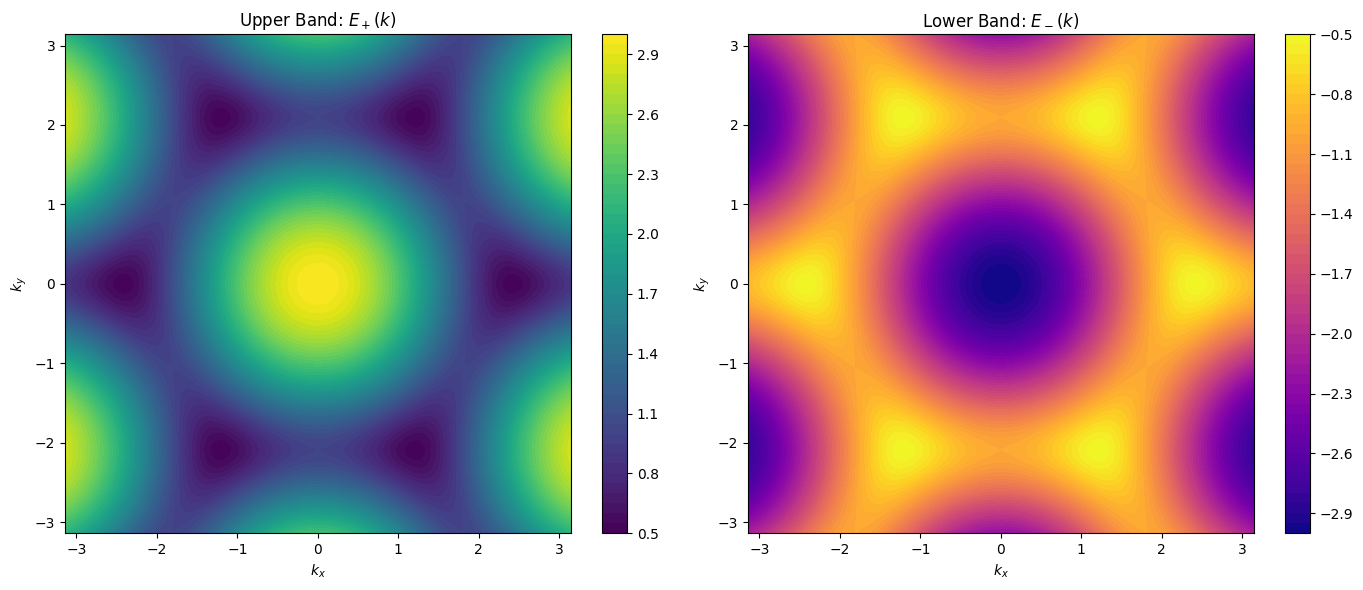

In [57]:
# Haldane Model Using Explicit Hamiltonian from Image
import numpy as np
import matplotlib.pyplot as plt

##constants##
t = 1.0              ##NN hopping (sets energy scale)##
t2 = 0.1             ##NNN hopping##
M = 0.0              ##sublattice mass term##

##NN and NNN vectors##
d1 = np.array([0.0, -1.0])
d2 = np.array([np.sqrt(3)/2, 0.5])
d3 = np.array([-np.sqrt(3)/2, 0.5])

b1 = d2 - d3
b2 = d3 - d1
b3 = d1 - d2
nnn_vectors = [b1, b2, b3]

##function to compute Haldane band energies##
def haldane_energy(kx, ky, t=1.0, t2=0.1, M=0.0):
    k = np.array([kx, ky])

    ## NN term: d_x and d_y (H_0(k)) ##
    f = 0
    for d in [d1, d2, d3]:
        f += np.exp(1j * np.dot(k, d))
    d_x = t * np.real(f)
    d_y = -t * np.imag(f)

    ## NNN and Mass term: d_z ##
    d_z = M
    for b in nnn_vectors:
        d_z += 2 * t2 * np.sin(np.dot(k, b))

    E = np.sqrt(d_x**2 + d_y**2 + d_z**2)
    return E, -E

##momentum grid##
kx_vals = np.linspace(-np.pi, np.pi, 300)
ky_vals = np.linspace(-np.pi, np.pi, 300)

E_plus = np.zeros((len(kx_vals), len(ky_vals)))
E_minus = np.zeros_like(E_plus)

for i, kx in enumerate(kx_vals):
    for j, ky in enumerate(ky_vals):
        E_plus[i, j], E_minus[i, j] = haldane_energy(kx, ky, t, t2, M)

##plotting both bands##
fig, ax = plt.subplots(1, 2, figsize=(14,6))
X, Y = np.meshgrid(kx_vals, ky_vals)

c1 = ax[0].contourf(X, Y, E_plus.T, levels=50, cmap='viridis')
plt.colorbar(c1, ax=ax[0])
ax[0].set_title("Upper Band: $E_+(k)$")
ax[0].set_xlabel("$k_x$")
ax[0].set_ylabel("$k_y$")

c2 = ax[1].contourf(X, Y, E_minus.T, levels=50, cmap='plasma')
plt.colorbar(c2, ax=ax[1])
ax[1].set_title("Lower Band: $E_-(k)$")
ax[1].set_xlabel("$k_x$")
ax[1].set_ylabel("$k_y$")

plt.tight_layout()
plt.show()

In [2]:
import numpy as np

n_sites = 6
t1, t2, phi = 1.0, 0.05, 0.2
lattice = [(i, (i + 1) % n_sites, 0) for i in range(n_sites)]+[(i, (i + 2) % n_sites, 1) for i in range(n_sites)]
spin = 2
H = 0.0 * np.zeros((n_sites*spin, n_sites*spin), dtype=complex)
for i, j, order in lattice:
    for s in range(spin):
        s1 = i * spin + s
        s2 = j * spin + s
        if order == 0:
            H[s1, s2] -= t1
            H[s2, s1] -= t1
        else:
            H[s1, s2] -= t2 * np.exp(1j * phi)
            H[s2, s1] -= t2 * np.exp(-1j * phi)

eigvals, eigvecs = np.linalg.eigh(H)
n_particles = 6
E_gs = np.sum(np.sort(eigvals)[:n_particles])
print(E_gs)

-8.000000000000002


In [43]:
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper
import numpy as np

n_sites = 6
t1, t2, phi = 1.0, 0, 0.2
lattice = [(i, (i + 1) % n_sites, 0) for i in range(n_sites)]+[(i, (i + 2) % n_sites, 1) for i in range(n_sites)]
spin = 2
hamiltonian = 0.0 * FermionicOp({})
for i, j, order in lattice:
    for s in range(spin):
        s1 = i * spin + s
        s2 = j * spin + s
        if order == 0:
            hamiltonian -= FermionicOp({
                f"+_{s1} -_{s2}": t1,
                f"+_{s2} -_{s1}": t1
            })
        else:
            hamiltonian -= FermionicOp({
                f"+_{s1} -_{s2}": t2*np.exp(1j*phi),
                f"+_{s2} -_{s1}": t2*np.exp(-1j*phi)
            })

mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(hamiltonian)

In [48]:
from qiskit_nature.second_q.hamiltonians import QuadraticHamiltonian
import numpy as np

n_sites = 6
t1, t2, phi = 1.0, 0.05, 0.2
lattice = [(i, (i + 1) % n_sites, 0) for i in range(n_sites)]+[(i, (i + 2) % n_sites, 1) for i in range(n_sites)]
spin = 2
H = 0.0 * np.zeros((n_sites*spin, n_sites*spin), dtype=complex)
for i, j, order in lattice:
    for s in range(spin):
        s1 = i * spin + s
        s2 = j * spin + s
        if order == 0:
            H[s1, s2] -= t1
            H[s2, s1] -= t1
        else:
            H[s1, s2] -= t2 * np.exp(1j * phi)
            H[s2, s1] -= t2 * np.exp(-1j * phi)

quadratic_hamiltonian = QuadraticHamiltonian(H)
transformation_matrix, diag_energies, _ = quadratic_hamiltonian.diagonalizing_bogoliubov_transform()

In [60]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

def U_EP(theta, phi):
    qc = QuantumCircuit(2)
    qc.rxx(theta/2, 0, 1)
    qc.ryy(theta/2, 0, 1)
    qc.cp(-phi, 0, 1)
    return qc

n_sites = 6
spin = 2

n_layers = 5
n_params = 4*n_sites+2*(n_sites*spin-1)*n_layers
params = ParameterVector('p', n_params)

n_occ = 6
ansatz = QuantumCircuit(n_sites*spin)
for i in range(n_occ):
    ansatz.x(i)
for i in range(2*n_sites):
    ansatz.rz(params[i], i)
for k in range(n_layers):
    for i in range(n_sites*spin-1):
        idx = 2*n_sites+(n_sites*spin-1)*k+2*i
        gate_params = params[idx:idx+2]
        ansatz.append(U_EP(gate_params[0], gate_params[1]), (i, i+1))
for i in range(2*n_sites):
    idx = 2*n_sites+2*(n_sites*spin-1)+i
    ansatz.rz(params[idx], i)

In [61]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_ibm_runtime import Session, Estimator
from qiskit_algorithms.optimizers import SPSA

max_iters = 5000
simulator = AerSimulator()
ansatz_circuit = transpile(ansatz, backend=simulator, optimization_level=3)

with Session(backend=simulator) as session:
    estimator = Estimator(mode=session)
    x0 = 2 * np.pi * np.random.random(ansatz.num_parameters)
    
    cost_history_dict = {
        "prev_vector": None,
        "iters": 0,
        "cost_history": [],
    }
    def cost_func(params):
        if cost_history_dict["iters"] >= max_iters:
            return cost_history_dict["cost_history"][-1]
    
        pub = (ansatz_circuit, [qubit_hamiltonian], [params])
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]
    
        cost_history_dict["iters"] += 1
        cost_history_dict["prev_vector"] = params
        cost_history_dict["cost_history"].append(energy)
    
        print(f"Iteration {cost_history_dict["iters"]}: {energy}")
        return energy
    
    spsa = SPSA(maxiter=max_iters)
    res = spsa.minimize(cost_func, x0=x0)

res.fun

Iteration 1: 0.0771484375
Iteration 2: 0.01806640625
Iteration 3: -0.2158203125
Iteration 4: 0.09375
Iteration 5: -0.048828125
Iteration 6: -0.1748046875
Iteration 7: -0.07568359375
Iteration 8: -0.183837890625
Iteration 9: -0.014892578125
Iteration 10: 0.120849609375
Iteration 11: -0.181640625
Iteration 12: -0.02099609375
Iteration 13: 0.0263671875
Iteration 14: -0.012939453125
Iteration 15: -0.15673828125
Iteration 16: 0.022705078125
Iteration 17: 0.11083984375
Iteration 18: -0.21826171875
Iteration 19: 0.278076171875
Iteration 20: -0.1923828125
Iteration 21: -0.11181640625
Iteration 22: 0.22021484375
Iteration 23: -0.28857421875
Iteration 24: -0.2158203125
Iteration 25: 0.139404296875
Iteration 26: -0.41259765625
Iteration 27: -0.127685546875
Iteration 28: 0.238037109375
Iteration 29: -0.06201171875
Iteration 30: -0.07177734375
Iteration 31: -0.07373046875
Iteration 32: 0.115966796875
Iteration 33: -0.095703125
Iteration 34: -0.016357421875
Iteration 35: -0.11181640625
Iteration 36:

np.float64(-4.54736328125)

In [7]:
from qiskit.synthesis import SuzukiTrotter
from qiskit.circuit.library import PauliEvolutionGate
from qiskit_nature.second_q.circuit.library import SlaterDeterminant, HartreeFock

t = 0.2
N_trot = 1
N_occ = 6
#occupied_orbitals = transformation_matrix[:N_occ, :]

st = SuzukiTrotter(reps=N_trot)
evolution = PauliEvolutionGate(qubit_hamiltonian, time=t)
evolution_circuit = st.synthesize(evolution)
initial_circuit = ansatz#SlaterDeterminant(occupied_orbitals)

In [8]:
from qiskit_algorithms import IterativePhaseEstimation
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler
from qiskit import transpile

backend, sampler = AerSimulator(), Sampler()
evolution_circuit, initial_circuit = transpile(evolution_circuit, backend=backend), transpile(initial_circuit, backend=backend)
iqpe = IterativePhaseEstimation(num_iterations=5, sampler=sampler)
result = iqpe.estimate(unitary=evolution_circuit, state_preparation=initial_circuit)

print(-2*np.pi*result.phase/t)

AlgorithmError: 'The primitive job failed!'